#Predicting Customer Churn

In [313]:
"""
Mount Drive and Import Libraries
"""

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ks_2samp
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.multitest import multipletests
from scipy.stats import chi2_contingency
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, recall_score, precision_score, f1_score, roc_curve, confusion_matrix
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Business Understanding

What is the problem that we are trying to solve?

Customer churn is a critical challenge for any subscription-based business. When customers leave, the company not only loses their current revenue but also the future value they would have generated had they stayed. Accurately predicting churn allows businesses to identify at-risk customers early and intervene with retention strategies such as targeted promotions or personalized offers.

In this project, I analyze data from Telco, a fictional telecommunications provider offering services such as phone, television, and internet (similar to Verizon, AT&T, Comcast, or T-Mobile). Telco is facing high customer turnover and seeks to build a predictive model to flag customers most likely to churn. This model will support the development of data-driven retention programs aimed at reducing customer loss and improving long-term profitability.

##### Analytic Approach

How can we use data to answer the business question?

Our goal is to predict a binary outcome (whether a customer churns or remains with the company) based on a set of features describing their profile and service usage.

Logistic Regression serves as a natural starting point. It uses the sigmoid function to turn a linear combination of features into a probabilitiy between 0 and 1. These probabilities can be interpreted as the estimated risk of churn for each customer. For classification, we use a standard decision threshold of 0.5.

To capture more complex, nonlinear relationships in the data, we will also train Random Forests and Gradient Boosting (XGBoost) models. Random Forests reduce variance by averaging predictions from many decision trees. Gradient Boosting builds trees sequentially to correct errors from previous iterations, often outperforming other algorithms.

To optimize model performance, we employ hyperparameter tuning via grid search, testing combinations of parameters such as tree depth, learning rate, regularization strength, etc. While this process increases computational time, it ensures that each model is configured to achieve its best possible performance within the tested range.

We also incorporate cross-validation to reduce overfitting. Instead of relying on a single train/test split, the data is divided into five folds. Each fold is used once as the validation set while the remaining folds are used for training. The performance scores across all folds are then averaged, providing a more reliable estimate of model effectiveness.

To maintain fairness in model evaluation, we use stratified cross-validation, ensuring that each fold preserves the same proportion of churned and retained customers as the full dataset. This prevents misleading performance estimates that can arise from imbalanced folds.

To evaluate performance, we emphasize recall, as the primary business objective is to identify as many at-risk customers as possible. Missing a potential churner (false negative) represents a lost opportunity for retention and future revenue. However, we also monitor precision to ensure that outreach efforts are efficient, since incorrectlly targeting non-churners results in unnecessary costs. This is an important tradeoff that we will need to consider once we know what kind of offers to target users with. For now, we want to make sure we capture as many at risk customers as possible.

### Data Understanding and Preparation
How do we get the data we are looking for? Does the data we collected represent the problem to be solved? What additional work is required to manipulate and work with the data?

##### Data Requirements

What data do you need to answer the question?

We would need a dataset with each row being a customer, and each column being a different trait like which services they were enrolled in, how long they were a customer for, etc. Most importantly, we need a column telling us whether or not a customer has churned. Once we have this, we can build a model that predicts churn based on a person's features.

##### Data Collection

Where is the data sourced from, and how will you receive the data?

This dataset was sourced from kaggle at the following link: https://www.kaggle.com/datasets/blastchar/telco-customer-churn. I have downloaded the dataset and will import it into this notebook for analysis and modeling. The site includes descriptions for each feature if needed.


From what we see below, each row is a unique customer and each column is a feature of that customer (including churn).

In [314]:
file_path = '/content/drive/My Drive/DS Portfolio Projects/Customer Churn Predictor/Telco-Customer-Churn.csv'
df = pd.read_csv(file_path)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [315]:
df.shape

(7043, 21)

In [316]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [317]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


##### Data Preparation + Feature Selection

Here we see that we don't have to worry about null values. We first need to remove customerID, as this is not needed for a predictive model.

In [318]:
df.drop('customerID', axis=1, inplace = True)

TotalCharges would not easily convert to a number because of empty values

In [319]:
# Find rows with " " in 'TotalCharges'
empty_TC_rows = df[df['TotalCharges'] == " "]
display(empty_TC_rows)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [320]:
df['TotalCharges'] = df['TotalCharges'].replace(" ", "0")
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

Let's change SeniorCitizen to yes/no for now

In [321]:
df['SeniorCitizen'] = df['SeniorCitizen'].map({0:'No', 1:'Yes'})

In [322]:
df.describe(include='all')

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043,7043,7043.000000,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043.000000,7043
unique,2,2,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,NaN,2
top,Male,No,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,NaN,No
freq,3555,5901,3641,4933,NaN,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,NaN,NaN,5174
mean,NaN,NaN,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,2279.734304,NaN
std,NaN,NaN,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,2266.794470,NaN
min,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,0.000000,NaN
25%,NaN,NaN,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,398.550000,NaN
50%,NaN,NaN,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,1394.550000,NaN
75%,NaN,NaN,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,3786.600000,NaN


Churn
No     5174
Yes    1869
Name: count, dtype: int64

Proportion:
Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64


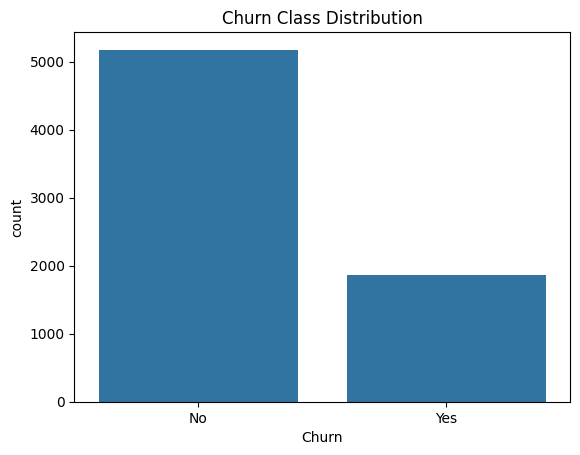

In [323]:
print(df['Churn'].value_counts())
print("\nProportion:")
print(df['Churn'].value_counts(normalize=True).round(3))

sns.countplot(x='Churn', data=df)
plt.title('Churn Class Distribution')
plt.show()

26.5% of customers have churned!
It would be nice if we could see the churn rate over time, but that data was not available for this project.

It would also be nice if we had feedback from churning customers, so that we could have self-reported data to analyze.

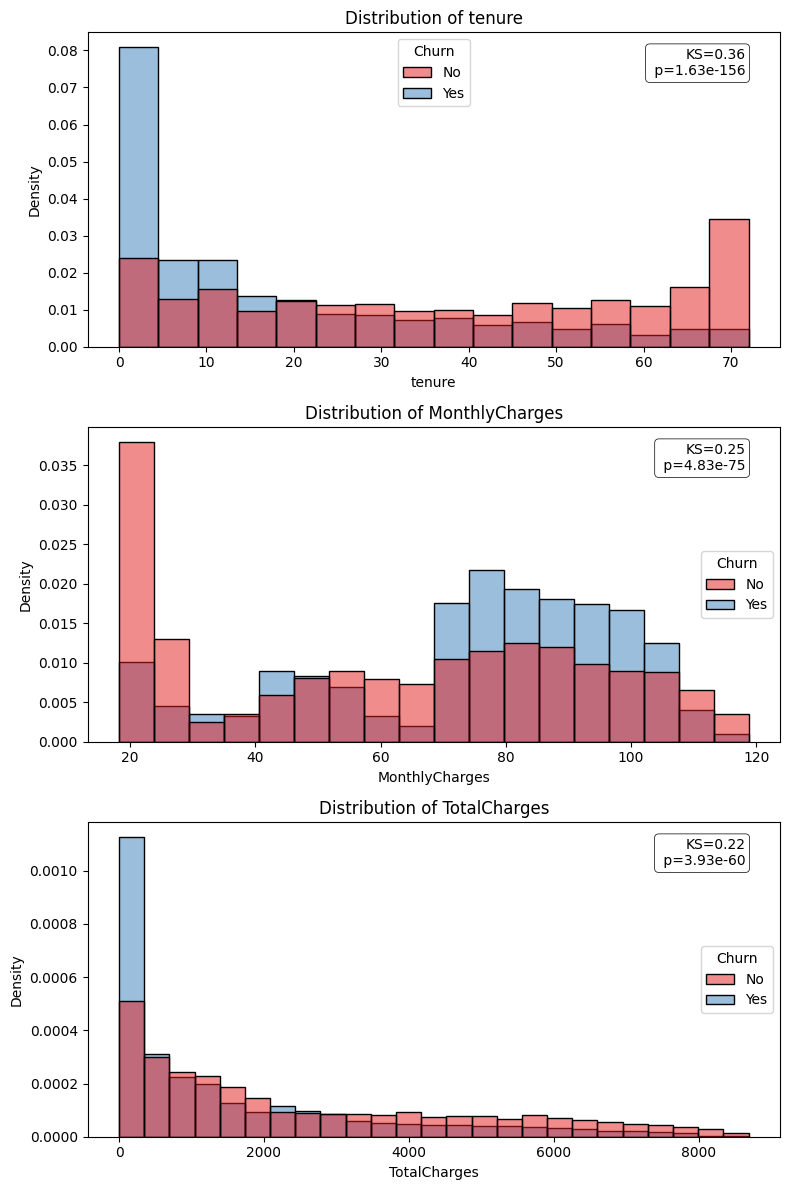

In [324]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
df[num_cols].describe().T

fig, axes = plt.subplots(len(num_cols), 1, figsize=(8, 12))

for ax, col in zip(axes, num_cols):
    # Subset values
    churn_yes = df.loc[df['Churn'] == 'Yes', col].dropna()
    churn_no  = df.loc[df['Churn'] == 'No',  col].dropna()

    # KS test
    ks_stat, ks_p = ks_2samp(churn_yes, churn_no)

    # Plot histogram
    sns.histplot(
        data=df,
        x=col,
        hue='Churn',
        stat='density',
        common_norm=False,
        ax=ax,
        palette='Set1'
    )

    # Title
    ax.set_title(f'Distribution of {col}')

    # Annotate KS result in upper right corner
    ax.text(
        0.95, 0.95,
        f"KS={ks_stat:.2f}\n p={ks_p:.2e}",
        transform=ax.transAxes,
        ha='right', va='top',
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='black', lw=0.5)
    )

plt.tight_layout()
plt.show()

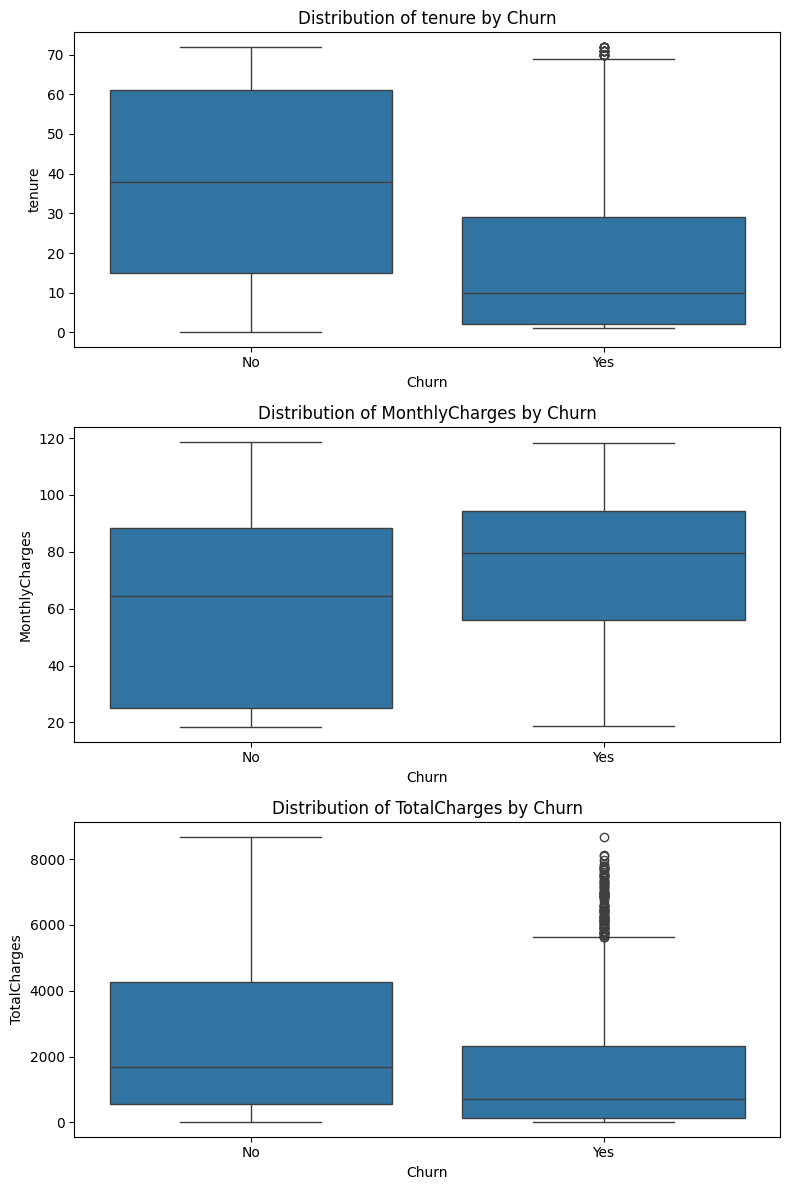

In [325]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(len(num_cols), 1, figsize=(8, 12))

for i, col in enumerate(num_cols):
    sns.boxplot(x='Churn', y=col, data=df, ax=axes[i])
    axes[i].set_title(f'Distribution of {col} by Churn')

plt.tight_layout()
plt.show()

In [326]:
# Compute correlations
df['ChurnFlag'] = df['Churn'].map({'No': 0, 'Yes': 1})  # numeric target for plots/calcs
num_corrs = df[num_cols].corrwith(df['ChurnFlag'])

# Put results in a nice DataFrame
num_corrs = num_corrs.to_frame('correlation').reset_index()
num_corrs.rename(columns={'index': 'feature'}, inplace=True)

print(num_corrs)

          feature  correlation
0          tenure    -0.352229
1  MonthlyCharges     0.193356
2    TotalCharges    -0.198324


In [327]:
# Expected total = MonthlyCharges × tenure
df['expected_total'] = df['MonthlyCharges'] * df['tenure']

# Check correlation between them
corr = df[['TotalCharges','expected_total']].corr().iloc[0,1]
print(f"Correlation between TotalCharges and MonthlyCharges*tenure: {corr:.3f}")

Correlation between TotalCharges and MonthlyCharges*tenure: 1.000


In [328]:
df.drop(columns=['TotalCharges', 'expected_total'], inplace=True)

Analysis of the numeric variables highlights clear differences between churned and retained customers. Churners tend to have shorter tenures, suggesting that many customers leave relatively soon after joining. They also show higher monthly charges, indicating that pricing may be a factor in their decision to leave. Finally, churners often have lower total charges, which reinforces the idea that much of the churn is driven by newer customers.

Kolmogorov–Smirnov (KS) tests confirm that the distributions of tenure, monthly charges, and total charges differ significantly between churned and non-churned groups, with tenure showing the strongest separation.

However, because TotalCharges is perfectly linear with MonthlyCharges*tenure, we will be dropping it to avoid multiconlinearity in logistic regression.

Based on these findings, tenure and monthly charges will be retained as inputs to the initial model, with the expectation that tenure in particular will provide strong predictive power.

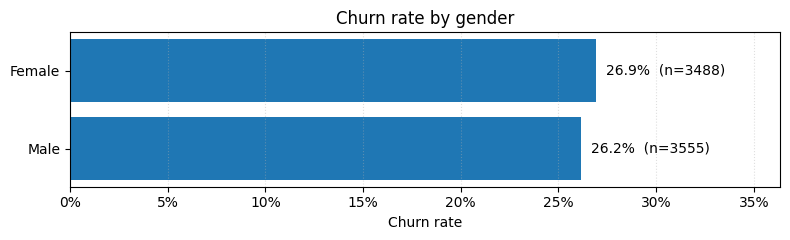

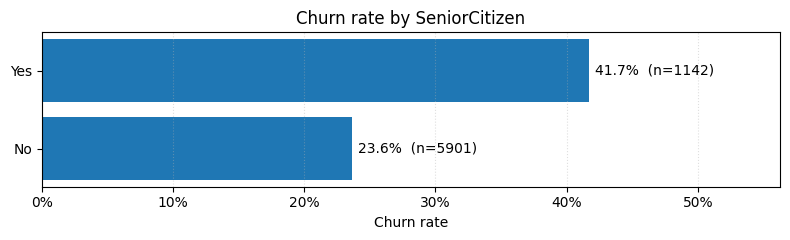

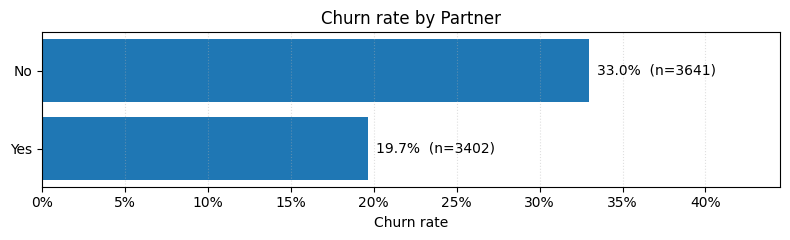

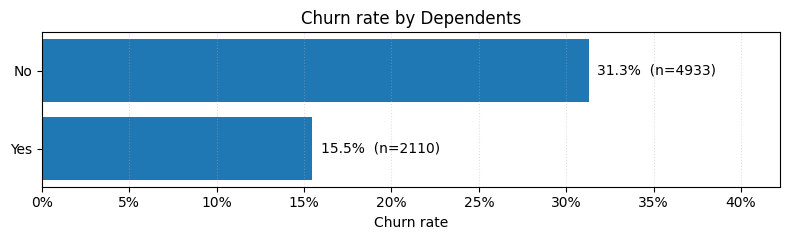

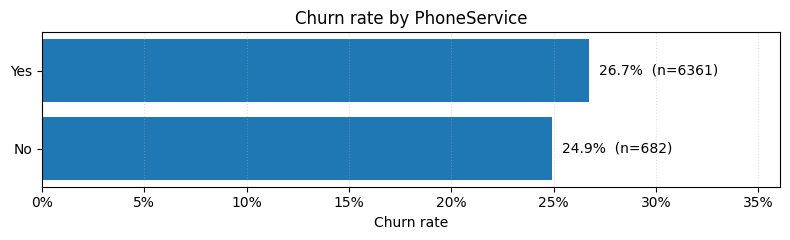

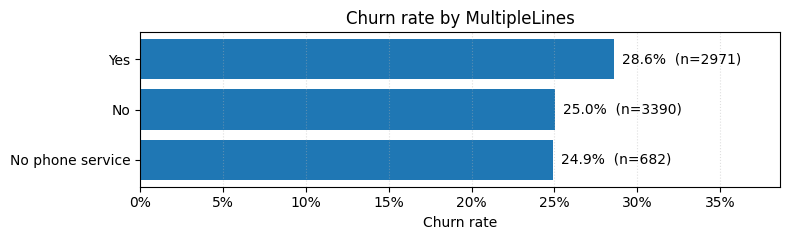

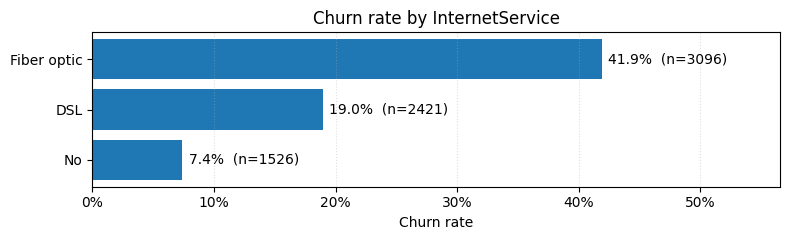

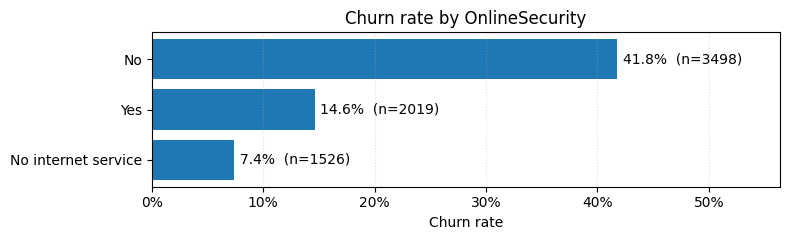

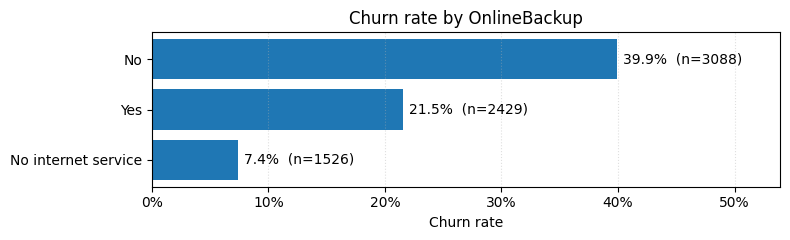

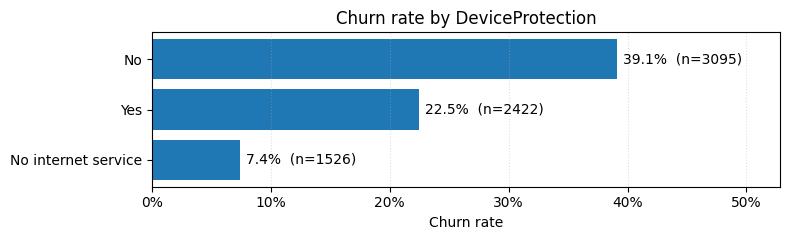

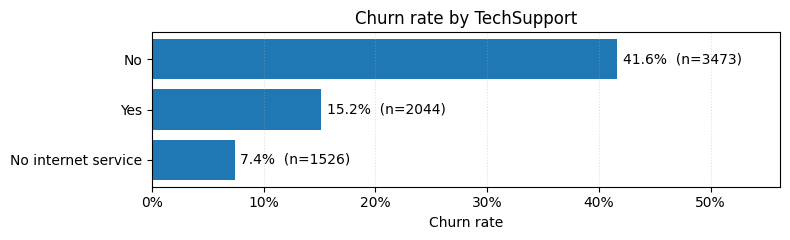

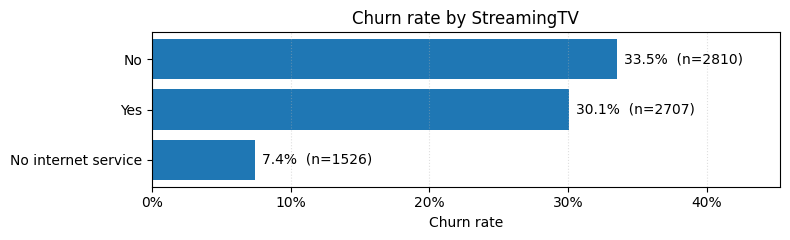

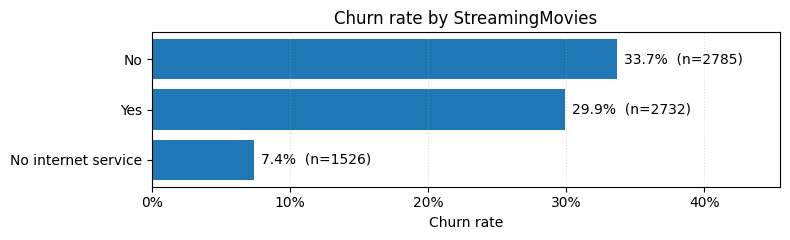

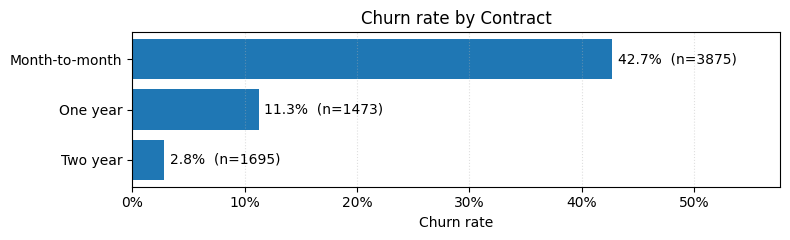

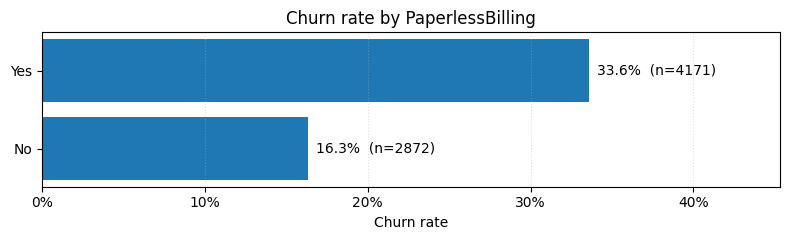

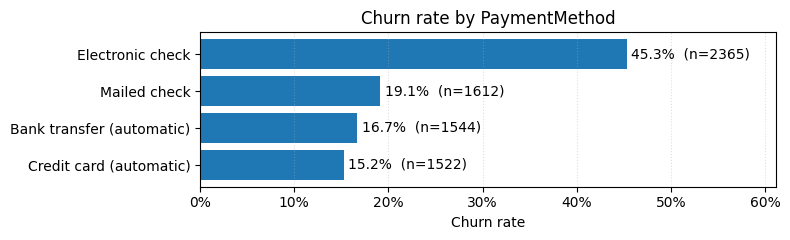

In [329]:
cat_cols = [
    'gender','SeniorCitizen','Partner','Dependents','PhoneService','MultipleLines',
    'InternetService','OnlineSecurity','OnlineBackup','DeviceProtection',
    'TechSupport','StreamingTV','StreamingMovies','Contract','PaperlessBilling','PaymentMethod'
]

for c in cat_cols:
    # compute churn rate and counts per level
    grp = (df.groupby(c)['ChurnFlag']
             .agg(churn_rate='mean', n='count')
             .sort_values('churn_rate', ascending=False)
             .reset_index())

    # dynamic figure height for readability
    h = max(2.5, 0.55 * len(grp))  # tweak as desired
    fig, ax = plt.subplots(figsize=(8, h))

    # horizontal bars
    ax.barh(grp[c].astype(str), grp['churn_rate'])
    ax.invert_yaxis()  # highest rate on top

    # format axes
    ax.set_xlabel('Churn rate')
    ax.set_title(f'Churn rate by {c}')
    ax.set_xlim(0, grp['churn_rate'].max() * 1.35)  # add some right padding

    # annotate with rate (%) and support (n)
    for i, (level, rate, n) in grp[[c,'churn_rate','n']].iterrows():
        ax.text(rate + 0.005, i, f"{rate:.1%}  (n={n})", va='center')

    # tidy grid
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
    ax.grid(axis='x', linestyle=':', alpha=0.4)
    plt.tight_layout()
    plt.show()


Initial analysis of categorical variables shows several strong churn patterns. Senior citizens churn at a rate of \~42%, compared to \~24% for non-seniors. Customers without partners churn more often (\~33%) than those with partners (\~20%), and customers without dependents churn more often (\~31%) than those with dependents (\~15%).

Service usage is also highly predictive. Customers with fiber optic internet churn at \~42%, far higher than DSL customers (\~19%) or those without internet (\~7%). Similarly, customers who lack add-on protections such as Online Security, Backup, Device Protection, or Tech Support churn at 39–42%, while those who have them churn closer to 15–22%.

Contract type is one of the strongest differentiators: month-to-month customers churn at \~43%, compared to \~11% for one-year and only \~3% for two-year contracts. Billing and payment methods also matter: churn is much higher among customers with paperless billing (34%) and especially those paying by electronic check (45%), compared to mailed checks (\~19%) or automatic bank/credit payments (15–17%).

To determine which categorical features are useful predictors of churn, I will apply two complementary statistical approaches:

Two-proportion z-tests (level vs. rest)

For each level of a categorical feature (e.g., “Fiber optic” in InternetService), I compared its churn rate to the churn rate of all other levels combined. This test checks whether the difference in churn proportions is statistically significant or simply due to random variation. A level with a significant difference (low p-value) provides evidence that this category meaningfully influences churn.

Chi-square test of independence with Cramér’s V

The Chi-square test evaluates whether there is an overall association between a categorical feature and churn. Cramér’s V provides an effect size (between 0 and 1), which allows us to measure the strength of that association. This is especially useful for comparing features with different numbers of categories.

By combining these tests:

The z-test highlights which specific category levels are driving churn.

The Chi-square/Cramér’s V test tells us which entire features have the strongest overall association with churn.

Only features that show consistent, non-trivial associations will be used in the model.

In [330]:
alpha = 0.05
use_fdr = True

cat_cols = [
    'gender','SeniorCitizen','Partner','Dependents','PhoneService','MultipleLines',
    'InternetService','OnlineSecurity','OnlineBackup','DeviceProtection',
    'TechSupport','StreamingTV','StreamingMovies','Contract','PaperlessBilling','PaymentMethod'
]

total_n = len(df)
total_churn = int(df['ChurnFlag'].sum())

all_rows = []

for c in cat_cols:
    for level, grp in df.groupby(c, dropna=False):
        n1 = len(grp)
        x1 = int(grp['ChurnFlag'].sum())
        n2 = total_n - n1
        x2 = total_churn - x1

        rate1 = x1 / n1 if n1 > 0 else np.nan
        rate2 = x2 / n2 if n2 > 0 else np.nan
        diff  = rate1 - rate2 if (np.isfinite(rate1) and np.isfinite(rate2)) else np.nan

        if n1 == 0 or n2 == 0:
            z_stat, p_val, ci_low, ci_high = np.nan, np.nan, np.nan, np.nan
        else:
            # Two-proportion z-test (two-sided)
            z_stat, p_val = proportions_ztest([x1, x2], [n1, n2], alternative='two-sided')

            # 95% CI for difference (normal approx)
            se = np.sqrt(rate1*(1-rate1)/n1 + rate2*(1-rate2)/n2)
            ci_low = diff - 1.96 * se
            ci_high = diff + 1.96 * se

        all_rows.append({
            'feature': c,
            'level': level,
            'n_level': n1,
            'churns_level': x1,
            'rate_level': rate1,
            'n_rest': n2,
            'rate_rest': rate2,
            'diff(level-rest)': diff,
            'z_stat': z_stat,
            'p_value': p_val,
            'ci95_low': ci_low,
            'ci95_high': ci_high
        })

out = pd.DataFrame(all_rows)

# Multiple-testing correction across ALL level-vs-rest tests
if use_fdr:
    mask = out['p_value'].notna()
    _, p_adj, _, _ = multipletests(out.loc[mask, 'p_value'], method='fdr_bh')
    out.loc[mask, 'p_adj'] = p_adj
    out['p_used'] = out['p_adj']
else:
    out['p_used'] = out['p_value']

out['abs_diff'] = out['diff(level-rest)'].abs()
out['p_fmt'] = out['p_used'].apply(lambda p: f"{p:.2e}" if pd.notna(p) else "nan")

# Split into significant vs not significant
sig_mask = out['p_used'] < alpha
sig_df = (out.loc[sig_mask]
            .sort_values(['p_used','abs_diff'], ascending=[True, False])
            .reset_index(drop=True))

nonsig_df = (out.loc[~sig_mask]
               .sort_values(['p_used','abs_diff'], ascending=[True, False])
               .reset_index(drop=True))

print(f"\n=== Significant (alpha={alpha}, {'FDR' if use_fdr else 'raw'} p-values) ===")
display(sig_df[['feature','level','n_level','rate_level','n_rest','rate_rest',
                'diff(level-rest)','z_stat','p_fmt','ci95_low','ci95_high']])

print("\n=== NOT Significant ===")
display(nonsig_df[['feature','level','n_level','rate_level','n_rest','rate_rest',
                   'diff(level-rest)','z_stat','p_fmt','ci95_low','ci95_high']])

print("\n=== Per-feature quick summary (top significant levels) ===")
for c in cat_cols:
    sub = sig_df[sig_df['feature'] == c].head(3)
    if len(sub):
        txt = "; ".join([f"{r.level}: diff={r['diff(level-rest)']:.3f}, p={r['p_used']:.1e}"
                         for _, r in sub.iterrows()])
        print(f"[{c}] {txt}")
    else:
        print(f"[{c}] no significant levels")


=== Significant (alpha=0.05, FDR p-values) ===


,feature,level,n_level,rate_level,n_rest,rate_rest,diff(level-rest),z_stat,p_fmt,ci95_low,ci95_high
0,Contract,Month-to-month,3875,0.427097,3168,0.067551,0.359546,33.997283,1.05e-251,0.341687,0.377406
1,OnlineSecurity,No,3498,0.417667,3545,0.115092,0.302576,28.754965,1.69e-180,0.283147,0.322004
2,TechSupport,No,3473,0.416355,3570,0.118487,0.297867,28.305470,4.24e-175,0.278343,0.317391
3,InternetService,Fiber optic,3096,0.418928,3947,0.144920,0.274007,25.849813,2.63e-146,0.253449,0.294566
4,Contract,Two year,1695,0.028319,5348,0.340501,-0.312183,-25.365892,5.16e-141,-0.327138,-0.297227
5,PaymentMethod,Electronic check,2365,0.452854,4678,0.170586,0.282268,25.337801,8.78e-141,0.259494,0.305043
6,OnlineBackup,No,3088,0.399288,3955,0.160809,0.238478,22.491687,3.08e-111,0.217755,0.259202
7,DeviceProtection,No,3095,0.391276,3948,0.166667,0.224610,21.188888,6.50e-99,0.203854,0.245365
8,InternetService,No,1526,0.074050,5517,0.318289,-0.244239,-19.125155,4.47e-81,-0.262231,-0.226247
9,OnlineSecurity,No internet service,1526,0.074050,5517,0.318289,-0.244239,-19.125155,4.47e-81,-0.262231,-0.226247



=== NOT Significant ===


,feature,level,n_level,rate_level,n_rest,rate_rest,diff(level-rest),z_stat,p_fmt,ci95_low,ci95_high
0,PhoneService,No,682,0.249267,6361,0.267096,-0.017830,-1.002202,3.32e-01,-0.052069,0.016410
1,PhoneService,Yes,6361,0.267096,682,0.249267,0.017830,1.002202,3.32e-01,-0.016410,0.052069
2,MultipleLines,No phone service,682,0.249267,6361,0.267096,-0.017830,-1.002202,3.32e-01,-0.052069,0.016410
3,gender,Female,3488,0.269209,3555,0.261603,0.007605,0.722749,4.70e-01,-0.013020,0.028231
4,gender,Male,3555,0.261603,3488,0.269209,-0.007605,-0.722749,4.70e-01,-0.028231,0.013020



=== Per-feature quick summary (top significant levels) ===
[gender] no significant levels
[SeniorCitizen] No: diff=-0.181, p=1.7e-36; Yes: diff=0.181, p=1.7e-36
[Partner] No: diff=0.133, p=2.5e-36; Yes: diff=-0.133, p=2.5e-36
[Dependents] No: diff=0.158, p=6.4e-43; Yes: diff=-0.158, p=6.4e-43
[PhoneService] no significant levels
[MultipleLines] Yes: diff=0.036, p=8.9e-04; No: diff=-0.029, p=7.1e-03
[InternetService] Fiber optic: diff=0.274, p=2.6e-146; No: diff=-0.244, p=4.5e-81; DSL: diff=-0.115, p=2.8e-25
[OnlineSecurity] No: diff=0.303, p=1.7e-180; No internet service: diff=-0.244, p=4.5e-81; Yes: diff=-0.167, p=1.8e-46
[OnlineBackup] No: diff=0.238, p=3.1e-111; No internet service: diff=-0.244, p=4.5e-81; Yes: diff=-0.076, p=6.6e-12
[DeviceProtection] No: diff=0.225, p=6.5e-99; No internet service: diff=-0.244, p=4.5e-81; Yes: diff=-0.061, p=3.6e-08
[TechSupport] No: diff=0.298, p=4.2e-175; No internet service: diff=-0.244, p=4.5e-81; Yes: diff=-0.160, p=4.2e-43
[StreamingTV] No i

In [331]:
def cramers_v_bias_corrected(chi2, n, r, k):
    phi2 = chi2 / n
    phi2corr = max(0, phi2 - (k-1)*(r-1)/(n-1))
    rcorr = r - (r-1)**2/(n-1)
    kcorr = k - (k-1)**2/(n-1)
    denom = min(kcorr-1, rcorr-1)
    return np.sqrt(phi2corr / denom) if denom > 0 else np.nan

rows = []
for c in cat_cols:
    # contingency table: rows=feature levels, cols=ChurnFlag(0/1)
    ct = pd.crosstab(df[c], df['ChurnFlag'])
    n = ct.values.sum()
    r, k = ct.shape

    # Chi-square test of independence
    chi2, p, dof, expected = chi2_contingency(ct, correction=False)

    # Effect size
    v = cramers_v_bias_corrected(chi2, n, r, k)

    # Small expected-counts diagnostic (rule of thumb: any expected < 5)
    min_expected = expected.min()
    small_cells = bool((expected < 5).sum())

    rows.append({
        'feature': c,
        'levels': r,
        'n': int(n),
        'chi2': chi2,
        'dof': int(dof),
        'p_value': p,
        'cramers_v': v,
        'min_expected_cell': float(min_expected),
        'any_expected_lt5': small_cells
    })

chi_df = pd.DataFrame(rows)

# Multiple-testing correction across features
if use_fdr:
    _, p_adj, _, _ = multipletests(chi_df['p_value'], method='fdr_bh')
    chi_df['p_adj'] = p_adj
    chi_df['p_used'] = chi_df['p_adj']
else:
    chi_df['p_used'] = chi_df['p_value']

# Formatting helpers
chi_df['p_fmt'] = chi_df['p_used'].apply(lambda p: f"{p:.2e}")
chi_df['cramers_v'] = chi_df['cramers_v'].astype(float)

# Split into significant vs not significant
sig_mask = chi_df['p_used'] < alpha
sig_df = (chi_df.loc[sig_mask]
          .sort_values(['p_used','cramers_v'], ascending=[True, False])
          .reset_index(drop=True))

nonsig_df = (chi_df.loc[~sig_mask]
             .sort_values(['p_used','cramers_v'], ascending=[True, False])
             .reset_index(drop=True))

print(f"\n=== Significant features (alpha={alpha}, {'FDR' if use_fdr else 'raw'} p-values) ===")
display(sig_df[['feature','levels','n','chi2','dof','p_fmt','cramers_v','any_expected_lt5','min_expected_cell']])

print("\n=== NOT significant features ===")
display(nonsig_df[['feature','levels','n','chi2','dof','p_fmt','cramers_v','any_expected_lt5','min_expected_cell']])

print("\n=== Quick summary: top features by Cramér's V (significant only) ===")
for _, r in sig_df.sort_values('cramers_v', ascending=False).head(5).iterrows():
    print(f"{r['feature']}: V={r['cramers_v']:.3f}, p={r['p_used']:.1e}, levels={r['levels']}")


=== Significant features (alpha=0.05, FDR p-values) ===


,feature,levels,n,chi2,dof,p_fmt,cramers_v,any_expected_lt5,min_expected_cell
0,Contract,3,7043,1184.596572,2,9.38e-257,0.409798,False,390.889820
1,OnlineSecurity,3,7043,849.998968,2,2.13e-184,0.347016,False,404.954423
2,TechSupport,3,7043,828.197068,2,7.70e-180,0.342526,False,404.954423
3,InternetService,3,7043,732.309590,2,3.83e-159,0.322037,False,404.954423
4,PaymentMethod,4,7043,648.142327,3,1.18e-139,0.302677,False,403.892943
5,OnlineBackup,3,7043,601.812790,2,5.55e-131,0.291850,False,404.954423
6,DeviceProtection,3,7043,558.419369,2,1.26e-121,0.281095,False,404.954423
7,StreamingMovies,3,7043,375.661479,2,5.34e-82,0.230351,False,404.954423
8,StreamingTV,3,7043,374.203943,2,9.83e-82,0.229902,False,404.954423
9,PaperlessBilling,2,7043,259.160974,1,4.18e-58,0.191468,False,762.142269



=== NOT significant features ===


,feature,levels,n,chi2,dof,p_fmt,cramers_v,any_expected_lt5,min_expected_cell
0,PhoneService,2,7043,1.004408,1,3.37e-01,0.000778,False,180.982252
1,gender,2,7043,0.522367,1,4.70e-01,0.000000,False,925.610109



=== Quick summary: top features by Cramér's V (significant only) ===
Contract: V=0.410, p=9.4e-257, levels=3
OnlineSecurity: V=0.347, p=2.1e-184, levels=3
TechSupport: V=0.343, p=7.7e-180, levels=3
InternetService: V=0.322, p=3.8e-159, levels=3
PaymentMethod: V=0.303, p=1.2e-139, levels=4


During the categorical feature analysis, I applied both two-proportion z-tests at the category level and Chi-square tests with Cramér's V at the feature level. Results consistently showed that PhoneService and gender have no statistically significant association with churn, and their effect sizes were negligible. This means that churn rates among customers with or without phone service are essentially the same, and male vs. female customers do not exhibit meaningful differences in churn behavior. Including features that carry no predictive signal can add noise or inflate model complexity without improving accuracy. For these reasons, I chose to drop PhoneService and gender from further modeling.

On the other hand, the top features are contract, online security, and tech support. Our visualizations that displayed the churn rate by feature level also show major discrepancies for our top features here, as discussed above.

In [332]:
df = df.drop(columns=["gender", "PhoneService","Churn"])
df.head()

,SeniorCitizen,Partner,Dependents,tenure,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,ChurnFlag
0,No,Yes,No,1,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,0
1,No,No,No,34,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,0
2,No,No,No,2,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,1
3,No,No,No,45,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,0
4,No,No,No,2,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,1


In [333]:
df.describe(include="all")

,SeniorCitizen,Partner,Dependents,tenure,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,ChurnFlag
count,7043,7043,7043,7043.000000,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043.000000
unique,2,2,2,NaN,3,3,3,3,3,3,3,3,3,2,4,NaN,NaN
top,No,No,No,NaN,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,NaN
freq,5901,3641,4933,NaN,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,NaN,NaN
mean,NaN,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,0.265370
std,NaN,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,0.441561
min,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,0.000000
25%,NaN,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,0.000000
50%,NaN,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,0.000000
75%,NaN,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,1.000000


In [334]:
df.dtypes

,0
SeniorCitizen,object
Partner,object
Dependents,object
tenure,int64
MultipleLines,object
InternetService,object
OnlineSecurity,object
OnlineBackup,object
DeviceProtection,object
TechSupport,object


#### Data Prep for logistic regression.
Numeric variables will be normalized and categorical variables will be one-hot encoded.

In [335]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
lr_df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
lr_df.columns

Index(['tenure', 'MonthlyCharges', 'ChurnFlag', 'SeniorCitizen_Yes',
       'Partner_Yes', 'Dependents_Yes', 'MultipleLines_No phone service',
       'MultipleLines_Yes', 'InternetService_Fiber optic',
       'InternetService_No', 'OnlineSecurity_No internet service',
       'OnlineSecurity_Yes', 'OnlineBackup_No internet service',
       'OnlineBackup_Yes', 'DeviceProtection_No internet service',
       'DeviceProtection_Yes', 'TechSupport_No internet service',
       'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')

In [336]:
num_cols = ['tenure', 'MonthlyCharges']  # TotalCharges already dropped
scaler = StandardScaler()
lr_df[num_cols] = scaler.fit_transform(df[num_cols])
lr_df[num_cols].describe()

,tenure,MonthlyCharges
count,7.043000e+03,7.043000e+03
mean,-2.421273e-17,-6.406285e-17
std,1.000071e+00,1.000071e+00
min,-1.318165e+00,-1.545860e+00
25%,-9.516817e-01,-9.725399e-01
50%,-1.372744e-01,1.857327e-01
75%,9.214551e-01,8.338335e-01
max,1.613701e+00,1.794352e+00


#### Data Prep for Random Forest and Gradient Boosting
No need for scaling numeric variables, but we must one hot encode the categorical ones.

In [337]:
rfgb_df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
rfgb_df.columns

Index(['tenure', 'MonthlyCharges', 'ChurnFlag', 'SeniorCitizen_Yes',
       'Partner_Yes', 'Dependents_Yes', 'MultipleLines_No phone service',
       'MultipleLines_Yes', 'InternetService_Fiber optic',
       'InternetService_No', 'OnlineSecurity_No internet service',
       'OnlineSecurity_Yes', 'OnlineBackup_No internet service',
       'OnlineBackup_Yes', 'DeviceProtection_No internet service',
       'DeviceProtection_Yes', 'TechSupport_No internet service',
       'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')

### Modeling + Evaluation

When we apply our strategy, do we see answers that address the business problem?

Does the data model answer the initial business question, or must we adjust the data?

#### Logistic Regression

In [338]:
X_lr = lr_df.drop(columns=['ChurnFlag'])
y_lr = lr_df['ChurnFlag']

X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_lr, y_lr, test_size=0.2, stratify=y_lr, random_state=42
)

In [339]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight='balanced', solver='lbfgs'),
    param_grid,
    cv=cv,
    scoring='recall',
    n_jobs=-1
)

grid.fit(X_train_lr, y_train_lr)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=LogisticRegression(class_weight='balanced',
                                          max_iter=1000),
             n_jobs=-1, param_grid={'C': [0.01, 0.1, 1, 10, 100]},
             scoring='recall')

In [340]:
log_reg = grid.best_estimator_

print("Best params:", grid.best_params_)

Best params: {'C': 0.1}


In [341]:
results = pd.DataFrame(grid.cv_results_)

results[['param_C', 'mean_test_score']] \
    .sort_values(by='mean_test_score', ascending=False)

,param_C,mean_test_score
1,0.10,0.795318
4,100.00,0.793980
2,1.00,0.793980
3,10.00,0.793311
0,0.01,0.785284


In [342]:
y_prob_lr = log_reg.predict_proba(X_test_lr)[:, 1]
y_pred_lr = (y_prob_lr >= 0.5).astype(int)

In [343]:
recall = recall_score(y_test_lr, y_pred_lr)
precision = precision_score(y_test_lr, y_pred_lr)
f1 = f1_score(y_test_lr, y_pred_lr)
roc = roc_auc_score(y_test_lr, y_prob_lr)

print("Recall:", recall)
print("Precision:", precision)
print("F1 Score:", f1)
print("ROC-AUC:", roc)

Recall: 0.7834224598930482
Precision: 0.5104529616724739
F1 Score: 0.6181434599156118
ROC-AUC: 0.8397349453615439


In [344]:
results = []

results.append({
    'Model': 'Logistic Regression',
    'Recall': recall,
    'Precision': precision,
    'F1': f1,
    'ROC_AUC': roc
})

#### Random Forest

In [345]:
X_rf = rfgb_df.drop('ChurnFlag', axis=1)
y_rf = rfgb_df['ChurnFlag']

X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf, y_rf, test_size=0.2, stratify=y_rf, random_state=42)

In [346]:
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid_rf,
    cv=cv,
    scoring='recall',
    n_jobs=-1
)

grid_rf.fit(X_train_rf, y_train_rf)

rf = grid_rf.best_estimator_

print("Best RF params:", grid_rf.best_params_)

Best RF params: {'max_depth': 5, 'n_estimators': 100}


In [347]:
y_prob_rf = rf.predict_proba(X_test_rf)[:, 1]
y_pred_rf = (y_prob_rf >= 0.5).astype(int)

In [348]:
recall_rf = recall_score(y_test_rf, y_pred_rf)
precision_rf = precision_score(y_test_rf, y_pred_rf)
f1_rf = f1_score(y_test_rf, y_pred_rf)
roc_rf = roc_auc_score(y_test_rf, y_prob_rf)

print("Recall:", recall_rf)
print("Precision:", precision_rf)
print("F1 Score:", f1_rf)
print("ROC-AUC:", roc_rf)

Recall: 0.8021390374331551
Precision: 0.4942339373970346
F1 Score: 0.6116207951070336
ROC-AUC: 0.8352760339972616


In [349]:
results.append({
    'Model': 'Random Forest',
    'Recall': recall_rf,
    'Precision': precision_rf,
    'F1': f1_rf,
    'ROC_AUC': roc_rf
})

#### Gradient Boosting

In [350]:
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0]
}
scale_pos_weight = (y_train_rf == 0).sum() / (y_train_rf == 1).sum()

grid_xgb = GridSearchCV(
    XGBClassifier(
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight
    ),
    param_grid_xgb,
    cv=cv,
    scoring='recall',
    n_jobs=-1
)

grid_xgb.fit(X_train_rf, y_train_rf)

xgb = grid_xgb.best_estimator_

print("Best XGB params:", grid_xgb.best_params_)

Best XGB params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [21:56:40] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [351]:
y_prob_xgb = xgb.predict_proba(X_test_rf)[:, 1]
y_pred_xgb = (y_prob_xgb >= 0.5).astype(int)

In [352]:
recall_xgb = recall_score(y_test_rf, y_pred_xgb)
precision_xgb = precision_score(y_test_rf, y_pred_xgb)
f1_xgb = f1_score(y_test_rf, y_pred_xgb)
roc_xgb = roc_auc_score(y_test_rf, y_prob_xgb)

print("Recall:", recall_xgb)
print("Precision:", precision_xgb)
print("F1 Score:", f1_xgb)
print("ROC-AUC:", roc_xgb)

Recall: 0.8074866310160428
Precision: 0.4967105263157895
F1 Score: 0.615071283095723
ROC-AUC: 0.8326590715337518


In [353]:
results.append({
    'Model': 'XGBoost',
    'Recall': recall_xgb,
    'Precision': precision_xgb,
    'F1': f1_xgb,
    'ROC_AUC': roc_xgb
})

#### Results

In [354]:
results_df = pd.DataFrame(results)
results_df.sort_values(by='Recall', ascending=False).round(3)

,Model,Recall,Precision,F1,ROC_AUC
2,XGBoost,0.807,0.497,0.615,0.833
1,Random Forest,0.802,0.494,0.612,0.835
0,Logistic Regression,0.783,0.510,0.618,0.840


In [355]:
model_outputs = {
    "Logistic Regression": (y_test_lr, y_prob_lr, y_pred_lr),
    "Random Forest": (y_test_rf, y_prob_rf, y_pred_rf),
    "XGBoost": (y_test_rf, y_prob_xgb, y_pred_xgb)
}

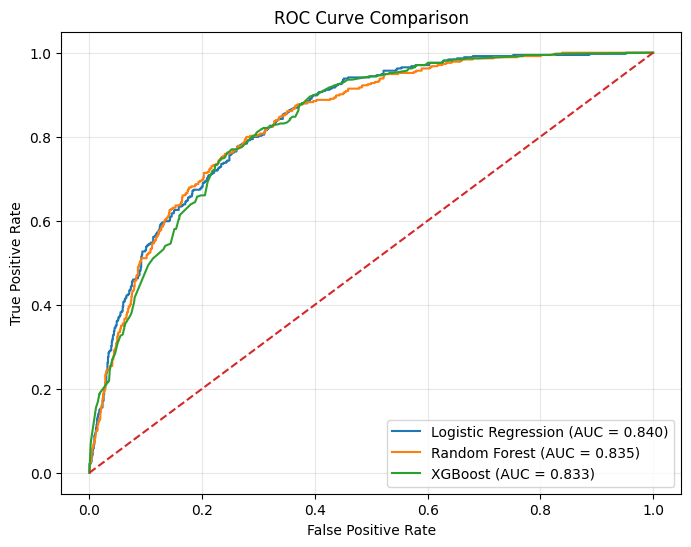

In [356]:
plt.figure(figsize=(8, 6))

for name, (y_true, y_prob_model, _) in model_outputs.items():
    fpr, tpr, _ = roc_curve(y_true, y_prob_model)
    auc = roc_auc_score(y_true, y_prob_model)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

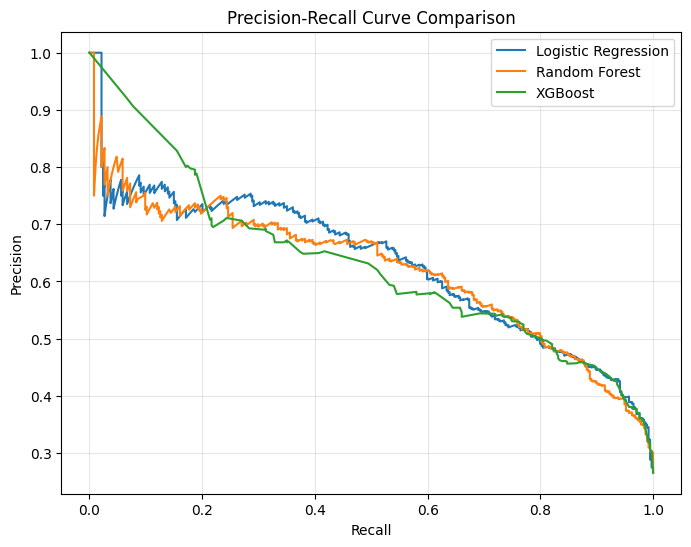

In [357]:
plt.figure(figsize=(8, 6))

for name, (y_true, y_prob_model, _) in model_outputs.items():
    precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_prob_model)
    plt.plot(recall_vals, precision_vals, label=name)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

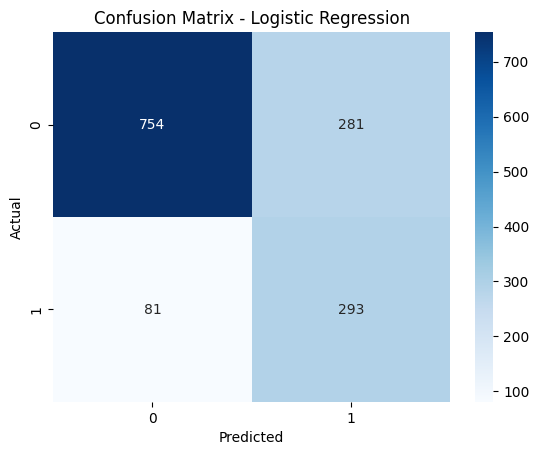

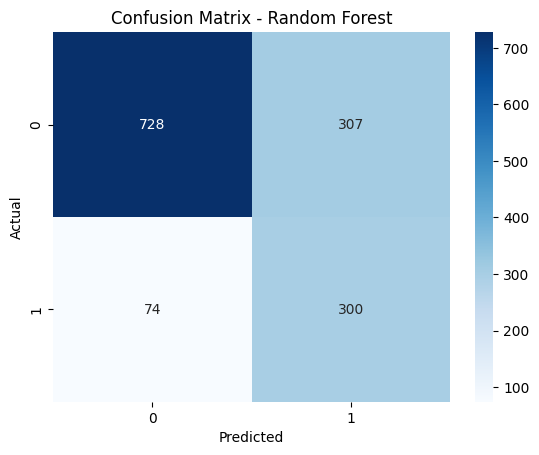

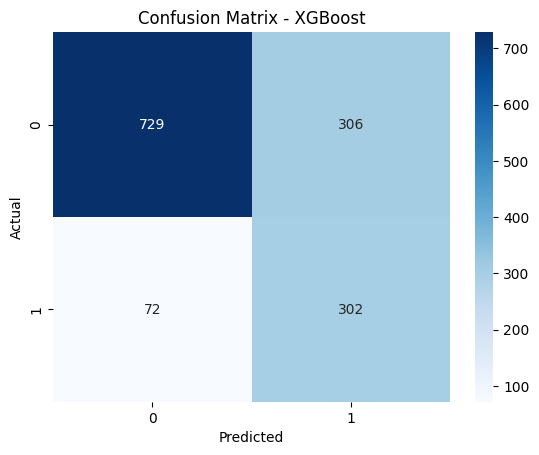

In [358]:
for name, (y_true, _, y_pred_model) in model_outputs.items():
    cm = confusion_matrix(y_true, y_pred_model)

    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

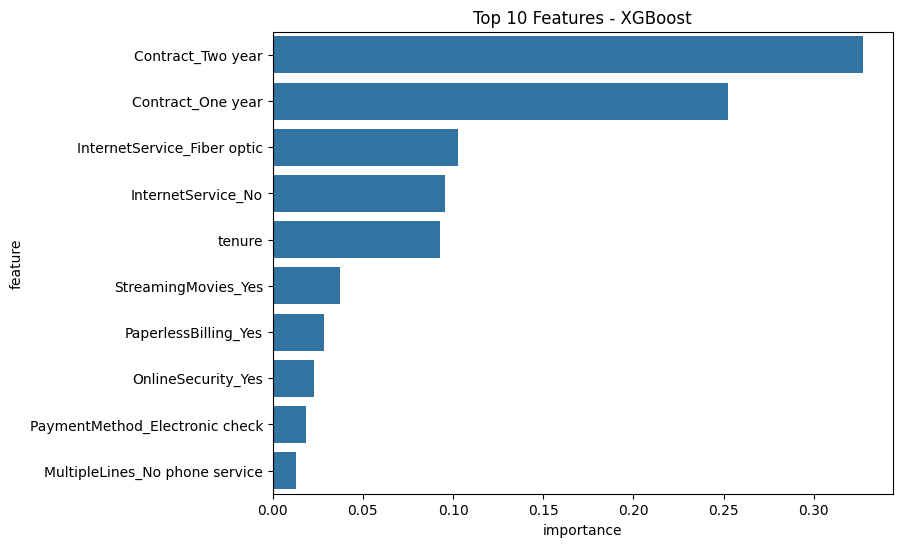

In [359]:
feature_importance = pd.DataFrame({
    'feature': X_rf.columns,   # IMPORTANT: use correct feature set
    'importance': xgb.feature_importances_
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(data=feature_importance.head(10), x='importance', y='feature')
plt.title("Top 10 Features - XGBoost")
plt.show()

#### Summary

Here, we see that XGBoost has performed the best with a recall of .807. This was selected as the final model because it achieved the highest recall while maintaining comparable precision to other models.

Looking at the feature importance of our XGBoost model, we see that the most impactful one is the contract types. Earlier in the analysis section, we noticed that these features were highly associated with churn.

Our model is ready to start solving the business problem. Now that we can mark at risk customers, we can have sales/marketing teams send offers that may convince them to stay.

### Deployment

Can we put the model into practice?

In a production setting, the selected model would be deployed as part of a customer retention pipeline. We would collect customer data on a regular basis and use it to generate a churn probability score for each active customer. Customers above a certain threshold would be flagged for targeted retention offers. We want to make sure that retention offers balance value to the customer and costs for our company to ensure we still profit. Our model's moderate precision means that we will be giving offers to customers who were not actually in danger of churning and we want to keep as much value from those customers as we can. There can be more expensive interventions with predictions that have a high level of confidence.

The model could be deployed as a scheduled batch process using a cloud based environment (AWS, GCP, zure) where predictions are generated and stored in a database accessible to marketing teams.



### Feedback

Can we get constructive feedback from the data and the stakeholder to answer the business question?

Now that the model is deployed, it is important that we continuously monitor performance. Key metrics are subject to change over time, so retraining the model may be necessary as customer behaviors change.

We also need to evaluate the real world impact of the model on the business. This means tracking things like the success rate of retention campaigns. We should also track the total cost of promotions and compare it to the revenue generated from retained customers to assess return on investment (ROI).